In [3]:
# Make own packages auto reload
%load_ext autoreload
%autoreload 2

# Mosaics

In [4]:
import numpy as np

from plot import plot_mosaics
from simulate import simulate_rgc_mosaics

np.random.seed(42)
n_mosaics = 3
center_noise = 0.1  # Position noise
diameter_noise = 0.1

mean_diameters = [10., 12.0, 15.0]  # Mean diameter for each mosaic
n_missing_list = [0, 0, 0]  # Missing cells per mosaic
overlap_factors = [1.1, 1.1, 1.1]  # No overlap, 15% overlap, 10% gaps

# Generate mosaics
groups, polygons, _, clipped = simulate_rgc_mosaics(
    n_mosaics=n_mosaics,
    mean_diameters=mean_diameters,
    center_noise=center_noise,
    diameter_noise=diameter_noise,
    n_missing_list=n_missing_list,
    overlap_factors=overlap_factors,
)

In [5]:
from polygons import compute_polygon_centers

centers = compute_polygon_centers(polygons)

In [6]:
from overlap import compute_iou_matrix

iou_matrix = compute_iou_matrix(polygons)

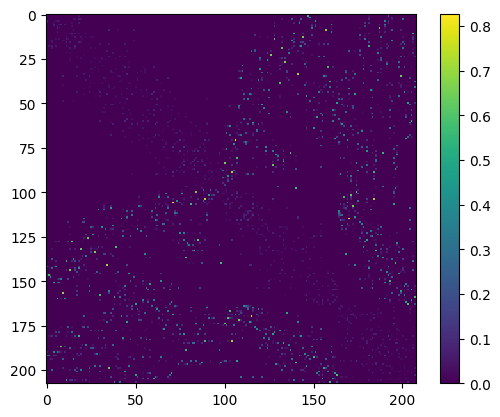

In [7]:
from matplotlib import pyplot as plt

plt.imshow(iou_matrix, interpolation='none')
plt.colorbar()
plt.show()

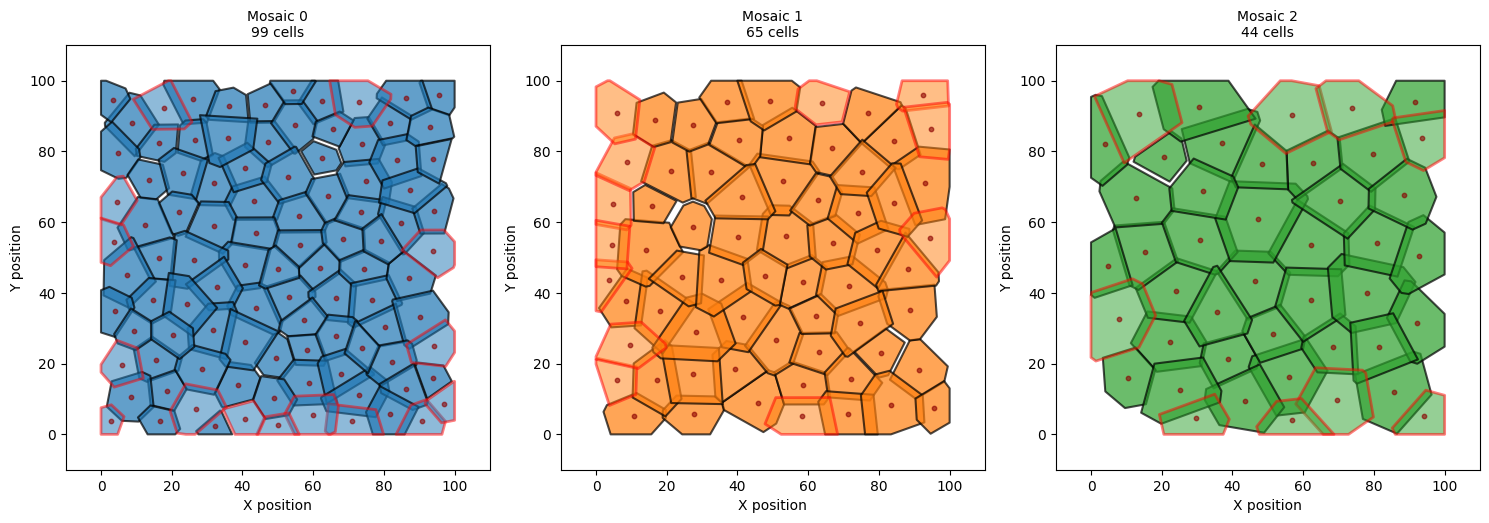

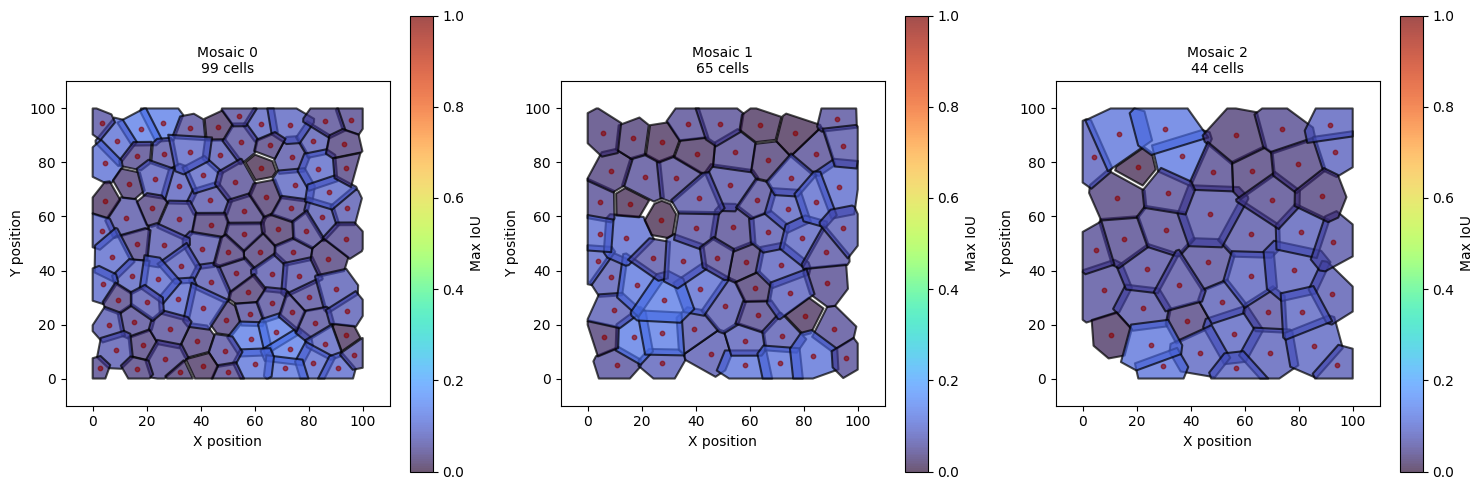

In [8]:
from matplotlib import pyplot as plt

plot_mosaics(groups, polygons, centers, highlight=clipped, mode='basic')
plt.show()

plot_mosaics(groups, polygons, centers, iou_matrix=iou_matrix, highlight=clipped, mode='iou')
plt.show()

# Features

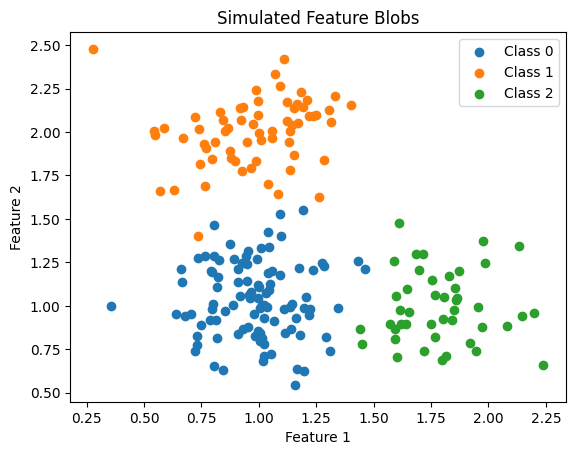

In [9]:
from plot import plot_blobs
from matplotlib import pyplot as plt
import numpy as np

u_groups, n_per_group = np.unique(groups, return_counts=True)
n_groups = len(u_groups)

assert n_groups == 3

feat_centers = [
    (1, 1),
    (1, 2),
    (1.8, 1),
]

feat_stds = [
    (0.2, 0.2),
    (0.2, 0.2),
    (0.2, 0.2),
]

X = []
y = []
for i, n_i in enumerate(n_per_group):
    center_i = feat_centers[i]
    stds_i = feat_stds[i]
    X_i = np.random.normal(center_i, stds_i, size=(n_i, 2))
    X.append(X_i)
    y.append(np.full(n_i, i))

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

plot_blobs(X=X, y=y)